In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("preprocessed_social_interaction.csv")

In [3]:
dataset

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,14,7.9,7.4,2.9,3.01,1.5,1,2,2,1,0,True,True,False
1,19,1.9,8.0,2.9,3.22,0.8,0,8,1,10,0,False,False,True
2,17,1.3,7.6,0.5,3.92,0.0,0,2,4,2,0,False,True,False
3,15,7.4,6.9,1.6,3.48,0.8,2,1,7,9,0,True,False,True
4,15,4.7,4.9,3.0,2.37,1.4,2,3,5,2,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,6.8,6.6,2.0,2.76,1.0,1,3,4,4,0,False,True,False
1196,16,2.3,8.0,1.9,2.12,0.4,0,7,4,4,0,True,False,False
1197,14,1.7,8.7,0.7,3.98,0.8,0,1,1,1,0,False,False,False
1198,15,3.9,8.5,2.1,3.19,0.6,0,7,9,9,0,True,False,False


In [4]:
dataset.columns

Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'social_interaction_level', 'stress_level', 'anxiety_level',
       'addiction_level', 'depression_label', 'gender_male',
       'platform_usage_Instagram', 'platform_usage_TikTok'],
      dtype='object')

In [5]:
independent=dataset[['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'social_interaction_level', 'stress_level', 'anxiety_level',
       'addiction_level','gender_male',
       'platform_usage_Instagram', 'platform_usage_TikTok']]

In [6]:
dependent=dataset[["depression_label"]]

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(independent, dependent, test_size=0.30,random_state=0)

In [13]:
from sklearn.tree import DecisionTreeClassifier
Classifier=DecisionTreeClassifier(criterion='gini', splitter='random')
Classifier=Classifier.fit(X_train,y_train)

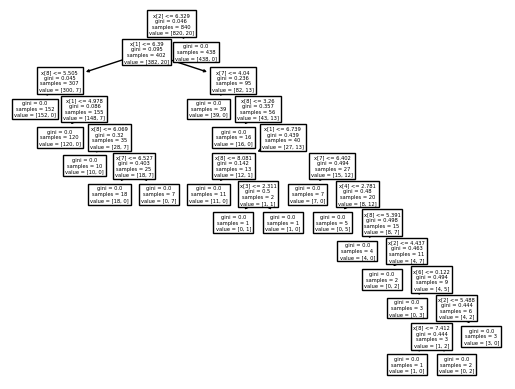

In [24]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(Classifier)
plt.show()

In [25]:
y_pred=Classifier.predict(X_test)

In [26]:
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)

In [27]:
r_score

0.9062255795780151

In [28]:
import pickle
filename="finalized_model_ML.sav"
pickle.dump(Classifier,open(filename,'wb'))

In [29]:
loaded_model=pickle.load(open("finalized_model_ML.sav",'rb'))
result=loaded_model.predict([[15,7.4,6.9,1.6,3.48,0.8,2,1,7,9,True,False,True]])

D:\Anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [30]:
result

array([0], dtype=int64)